<a href="https://colab.research.google.com/github/DilemmaFixer3/MZKN_labs/blob/main/Lab2_Variant1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №2. Візуалізація та наукове представлення даних
**Варіант 1** (файл `Variant_1.txt`).

In [1]:
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, sosfiltfilt, savgol_filter, medfilt
from scipy.optimize import curve_fit

os.makedirs("figures", exist_ok=True)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

## Завдання №1. Генерація сигналу I(f) = sin(2π·f·τ + φ)
τ = 0,1 нс, φ = 0, f від 10 до 70 ГГц з кроком 0,2 ГГц. Використовуємо `linspace` (301 точка, кінець включено).

In [2]:
tau = 0.1
f = np.round(np.linspace(10, 70, 301), 1)

def intensity(f, phi=0.0):
    return np.sin(2 * np.pi * f * tau + phi)

I = intensity(f)
np.savetxt("signal.txt", np.column_stack([f, I]), fmt="%.6f", delimiter="\t", header="f_GHz\tI")
data = np.loadtxt("signal.txt", skiprows=1)      # зчитуємо файл назад
f, I = data[:, 0], data[:, 1]
print("Точок:", len(f), "| діапазон:", f[0], "-", f[-1])

Точок: 301 | діапазон: 10.0 - 70.0


**а) графік залежності**

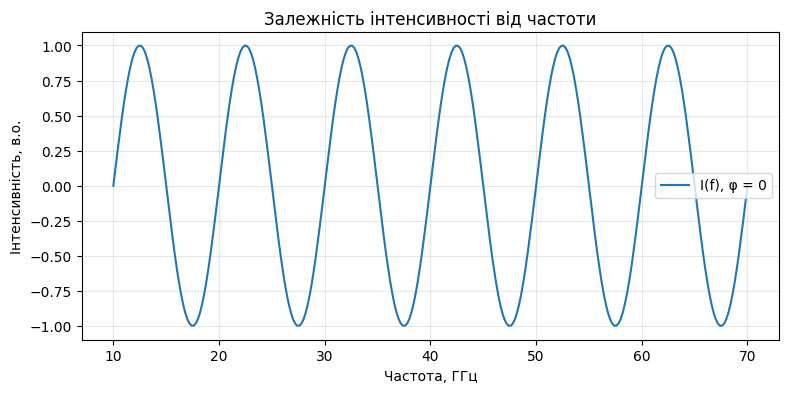

In [3]:
fig, ax = plt.subplots()
ax.plot(f, I, label="I(f), φ = 0")
ax.set_xlabel("Частота, ГГц"); ax.set_ylabel("Інтенсивність, в.о.")
ax.set_title("Залежність інтенсивності від частоти"); ax.legend()
fig.savefig("figures/t1a.png", dpi=200, bbox_inches="tight"); plt.show()

**б) мінімум, максимум, нулі, перетини з осями.**
Нулі: |I| < 1e-9 (через точність float значення «майже нуль»). Теоретично нулі у f = 5k ГГц, тобто 10, 15, …, 70.
З віссю ординат (f = 0) графік не перетинається, бо f ∈ [10; 70]; ліва межа графіка f = 10 і там I = 0.

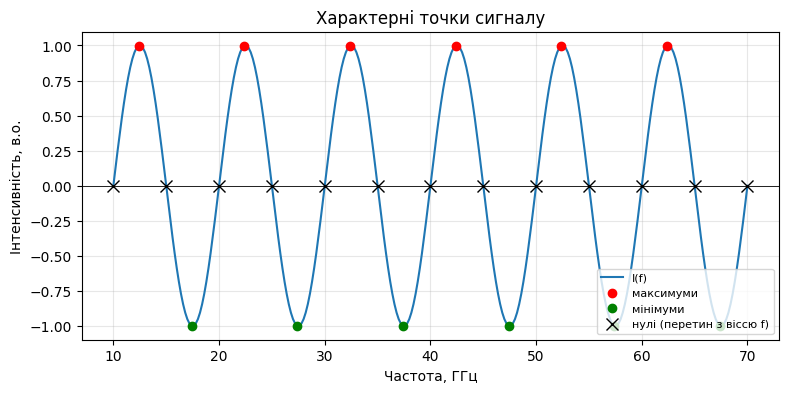

Max = 0.998 у f = [12.4 22.4 32.4 42.4 52.4 62.4]
Min = -0.998 у f = [17.4 27.4 37.4 47.4 57.4 67.4]
Нулі, ГГц: [10. 15. 20. 25. 30. 35. 40. 45. 50. 55. 60. 65. 70.] | кількість: 13


In [4]:
mx, _ = find_peaks(I); mn, _ = find_peaks(-I)
zero_idx = np.where(np.abs(I) < 1e-9)[0]
fig, ax = plt.subplots()
ax.plot(f, I, label="I(f)")
ax.axhline(0, color="black", lw=0.6)
ax.plot(f[mx], I[mx], "ro", label="максимуми")
ax.plot(f[mn], I[mn], "go", label="мінімуми")
ax.plot(f[zero_idx], I[zero_idx], "kx", ms=8, label="нулі (перетин з віссю f)")
ax.set_xlabel("Частота, ГГц"); ax.set_ylabel("Інтенсивність, в.о.")
ax.set_title("Характерні точки сигналу"); ax.legend(loc="lower right", fontsize=8)
fig.savefig("figures/t1b.png", dpi=200, bbox_inches="tight"); plt.show()
print("Max =", I.max().round(4), "у f =", f[mx]); print("Min =", I.min().round(4), "у f =", f[mn])
print("Нулі, ГГц:", f[zero_idx], "| кількість:", len(zero_idx))

**в) два графіки зі зсувом фази π/2**

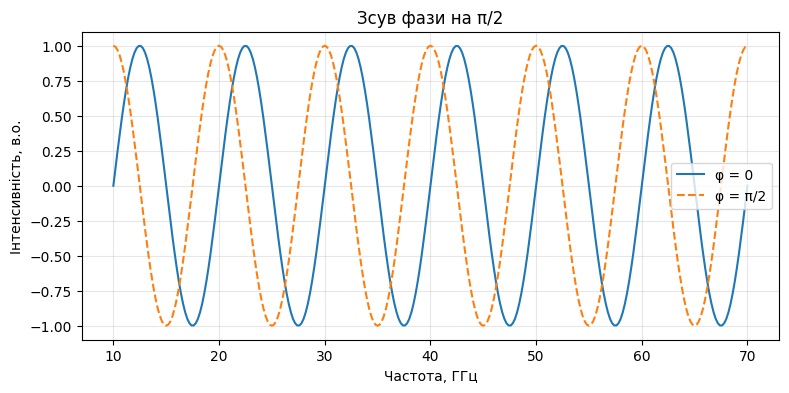

In [5]:
fig, ax = plt.subplots()
ax.plot(f, intensity(f), label="φ = 0")
ax.plot(f, intensity(f, np.pi / 2), "--", label="φ = π/2")
ax.set_xlabel("Частота, ГГц"); ax.set_ylabel("Інтенсивність, в.о."); ax.set_title("Зсув фази на π/2"); ax.legend()
fig.savefig("figures/t1c.png", dpi=200, bbox_inches="tight"); plt.show()

**г) три графіки у різних вікнах одного рисунка**

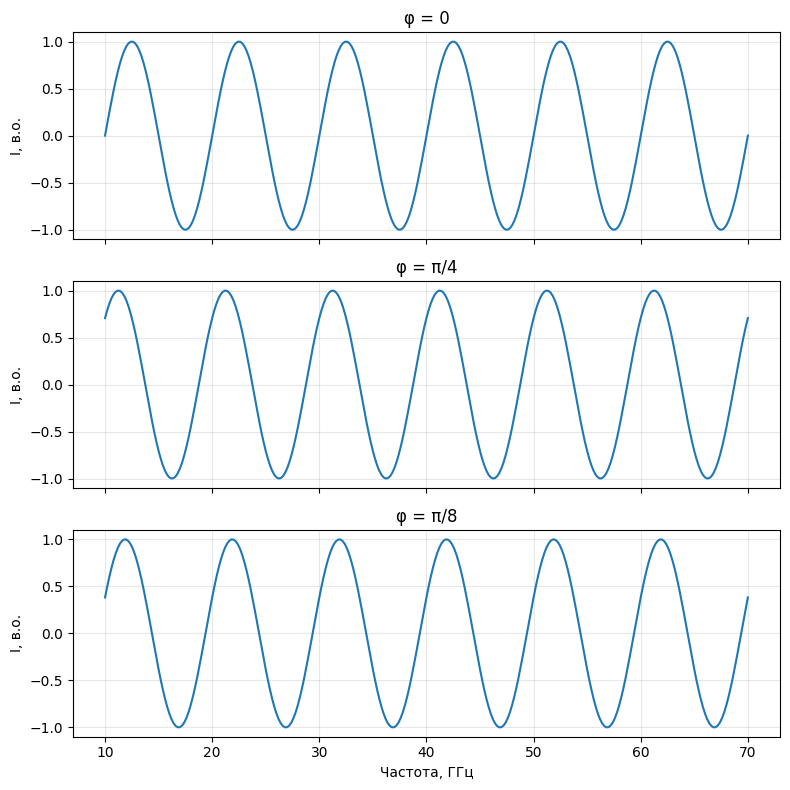

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
for ax, ph, name in zip(axes, [0, np.pi / 4, np.pi / 8], ["φ = 0", "φ = π/4", "φ = π/8"]):
    ax.plot(f, intensity(f, ph)); ax.set_title(name); ax.set_ylabel("I, в.о.")
axes[-1].set_xlabel("Частота, ГГц"); fig.tight_layout()
fig.savefig("figures/t1d.png", dpi=200, bbox_inches="tight"); plt.show()

**д) кругові діаграми: додатні та від'ємні значення у діапазонах 10–30, 31–50, 51–70 ГГц**
Межі взято як: 10 ≤ f ≤ 30, 30 < f ≤ 50, 50 < f ≤ 70. Нульові значення (|I| < 1e-9) у підрахунок не входять.

10–30 ГГц додатних: 48 від'ємних: 48 нулів: 5
31–50 ГГц додатних: 48 від'ємних: 48 нулів: 4
51–70 ГГц додатних: 48 від'ємних: 48 нулів: 4


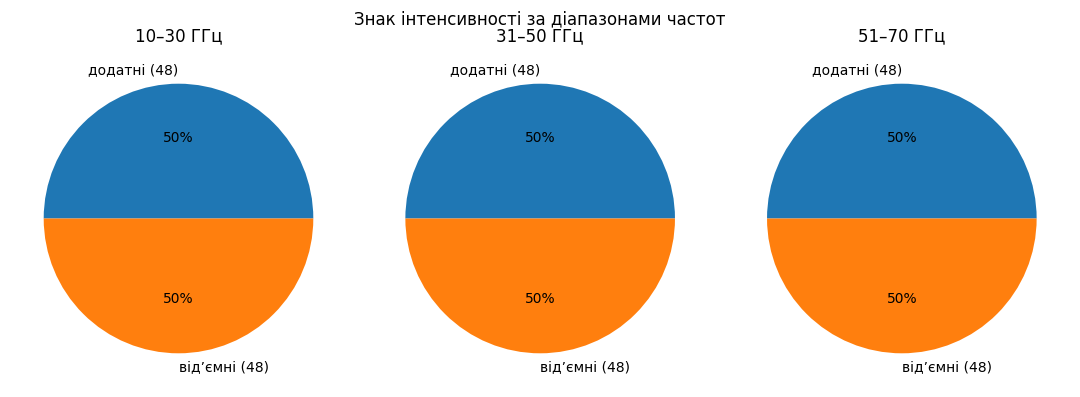

In [7]:
ranges = [("10–30 ГГц", (f >= 10) & (f <= 30)), ("31–50 ГГц", (f > 30) & (f <= 50)), ("51–70 ГГц", (f > 50) & (f <= 70))]
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, (name, m) in zip(axes, ranges):
    npos, nneg = int(np.sum(I[m] > 1e-9)), int(np.sum(I[m] < -1e-9))
    ax.pie([npos, nneg], labels=[f"додатні ({npos})", f"від’ємні ({nneg})"], autopct="%.0f%%")
    ax.set_title(name); print(name, "додатних:", npos, "від'ємних:", nneg, "нулів:", int(np.sum(np.abs(I[m]) <= 1e-9)))
fig.suptitle("Знак інтенсивності за діапазонами частот"); fig.tight_layout()
fig.savefig("figures/t1e.png", dpi=200, bbox_inches="tight"); plt.show()

## Завдання №2. Обробка експериментальних даних (Variant_1.txt)
### 2.1. Завантаження і візуалізація
Колонки: 1 – номер виміру, 2 – кут енкодера, 3 – кут повороту зразка, 4 – інтенсивність.
**Увага:** у файлі десяткова **кома**, тому потрібен `decimal=","` (інакше числа прочитаються як текст).
Кут зразка змінюється ступінчасто (на один кут припадає багато вимірів), тому всі фільтри застосовуємо
по номеру виміру (рівномірна «часова» вісь), а на графіках підписуємо кутом зразка.

(17214, 4) | пропусків: 0
               n        enc      angle          I
count  17214.000  17214.000  17214.000  17214.000
mean    8606.500      9.654     41.449     -0.362
std     4969.398      5.839     17.666      0.010
min        0.000      0.000     13.324     -0.391
25%     4303.250      5.029     24.794     -0.370
50%     8606.500      8.912     41.735     -0.362
75%    12909.750     13.147     58.588     -0.355
max    17213.000     22.500     72.706     -0.324


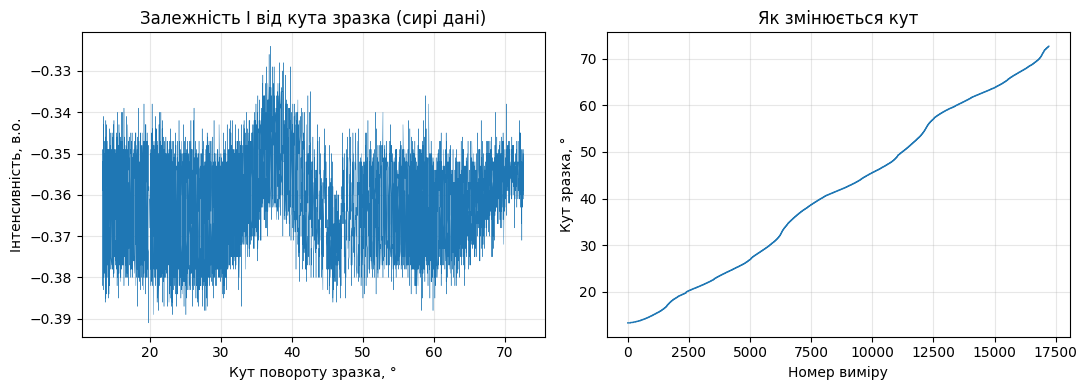

In [9]:
df = pd.read_csv("Variant_1.txt", sep="\t", header=None, decimal=",", names=["n", "enc", "angle", "I"])
n, x, y = df["n"].values, df["angle"].values, df["I"].values
print(df.shape, "| пропусків:", int(df.isna().sum().sum()))
print(df.describe().round(3))
def ang(idx):                     # індекс відліку (можливо дробовий) -> кут зразка
    return np.interp(idx, n, x)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, y, lw=0.3); ax[0].set_xlabel("Кут повороту зразка, °"); ax[0].set_ylabel("Інтенсивність, в.о.")
ax[0].set_title("Залежність I від кута зразка (сирі дані)")
ax[1].plot(n, x, lw=1); ax[1].set_xlabel("Номер виміру"); ax[1].set_ylabel("Кут зразка, °"); ax[1].set_title("Як змінюється кут")
fig.tight_layout(); fig.savefig("figures/t2_1.png", dpi=200, bbox_inches="tight"); plt.show()

### 2.2. Фільтри Баттерворта (ФНЧ – шум, ФВЧ – постійна складова)
Використано `sosfiltfilt` (те саме, що `filtfilt`, але стійкіше при дуже малих частотах зрізу; фазу не зсуває).
Wn – частка від частоти Найквіста.

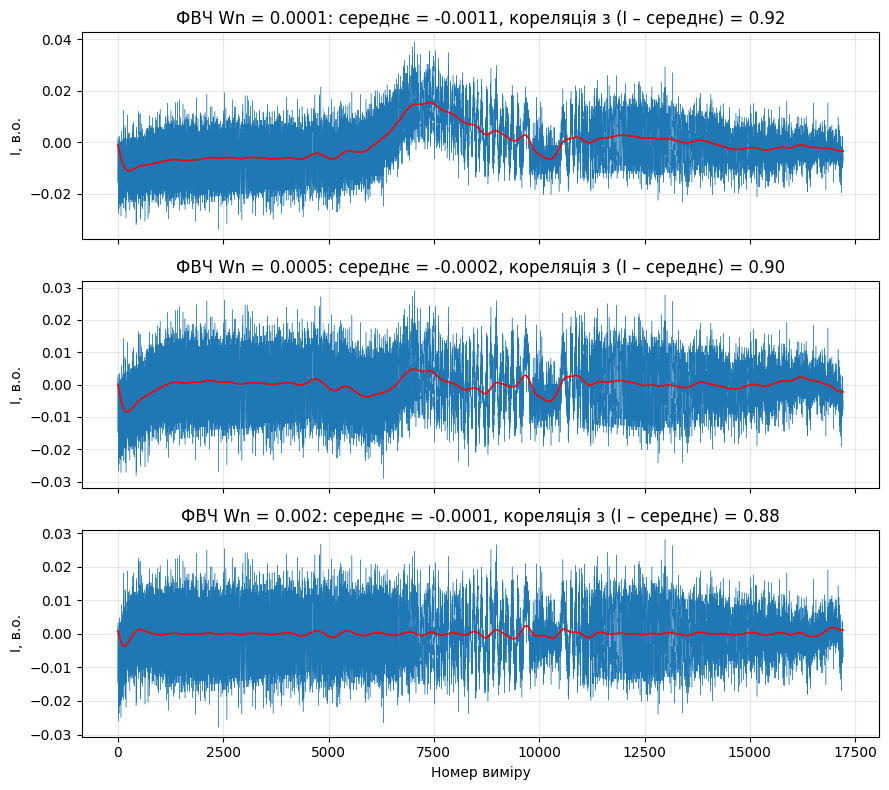

In [10]:
def lowpass(s, wn, N=3):  return sosfiltfilt(butter(N, wn, "low", output="sos"), s)
def highpass(s, wn, N=3): return sosfiltfilt(butter(N, wn, "high", output="sos"), s)

# ФВЧ: три значення; обираємо те, що прибирає зсув, але не псує форму
ref = y - y.mean()
hp_vals = [0.0001, 0.0005, 0.002]
fig, axes = plt.subplots(len(hp_vals), 1, figsize=(9, 8), sharex=True)
for ax, w in zip(axes, hp_vals):
    h = highpass(y, w); ax.plot(n, h, lw=0.3); ax.plot(n, lowpass(h, 0.004), "r", lw=1.2)
    ax.set_title(f"ФВЧ Wn = {w}: середнє = {h.mean():.4f}, кореляція з (I – середнє) = {np.corrcoef(h, ref)[0,1]:.2f}")
    ax.set_ylabel("I, в.о.")
axes[-1].set_xlabel("Номер виміру"); fig.tight_layout(); fig.savefig("figures/t2_2hp.png", dpi=200, bbox_inches="tight"); plt.show()

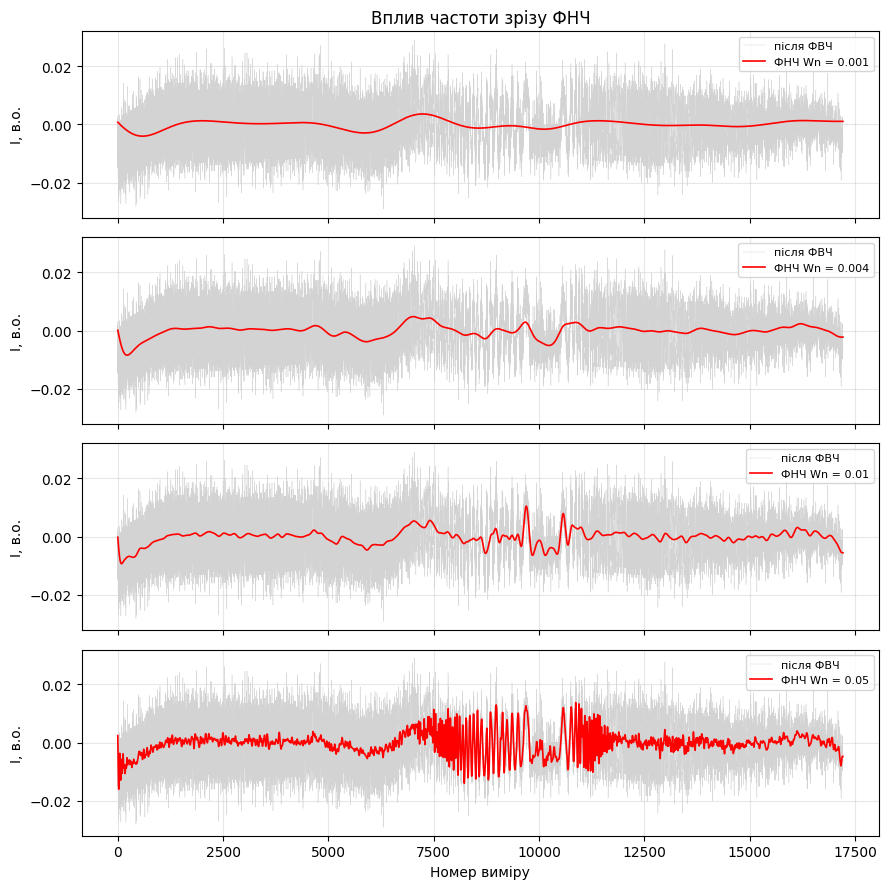

   Wn ФНЧ  максимумів  мінімумів
0   0.001           3          4
1   0.004           5          5
2   0.010          18         18
3   0.050         162        163
Кількість максимумів залежно від Wn: [(0.002, 5), (0.003, 5), (0.004, 5), (0.005, 5), (0.0075, 14), (0.01, 18), (0.02, 41)]


In [11]:
HP_WN = 0.0005
y_hp = highpass(y, HP_WN)
lp_vals = [0.001, 0.004, 0.01, 0.05]
fig, axes = plt.subplots(len(lp_vals), 1, figsize=(9, 9), sharex=True)
rows = []
for ax, w in zip(axes, lp_vals):
    s = lowpass(y_hp, w)
    p, _ = find_peaks(s, prominence=0.002); t, _ = find_peaks(-s, prominence=0.002)
    rows.append((w, len(p), len(t)))
    ax.plot(n, y_hp, color="lightgray", lw=0.3, label="після ФВЧ"); ax.plot(n, s, "r", lw=1.2, label=f"ФНЧ Wn = {w}")
    ax.set_ylabel("I, в.о."); ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Номер виміру"); axes[0].set_title("Вплив частоти зрізу ФНЧ")
fig.tight_layout(); fig.savefig("figures/t2_2lp.png", dpi=200, bbox_inches="tight"); plt.show()
print(pd.DataFrame(rows, columns=["Wn ФНЧ", "максимумів", "мінімумів"]))
scan = [(w, len(find_peaks(lowpass(y_hp, w), prominence=0.002)[0])) for w in [0.002, 0.003, 0.004, 0.005, 0.0075, 0.01, 0.02]]
print("Кількість максимумів залежно від Wn:", scan)

**Вибір:** ФВЧ Wn = 0,0005 (прибирає зсув, форму зберігає); ФНЧ Wn = 0,004 – у діапазоні 0,003–0,005 кількість
піків стабільна (5 + 5), при більших Wn «розмножуються» шумові піки, при менших – зникають справжні.

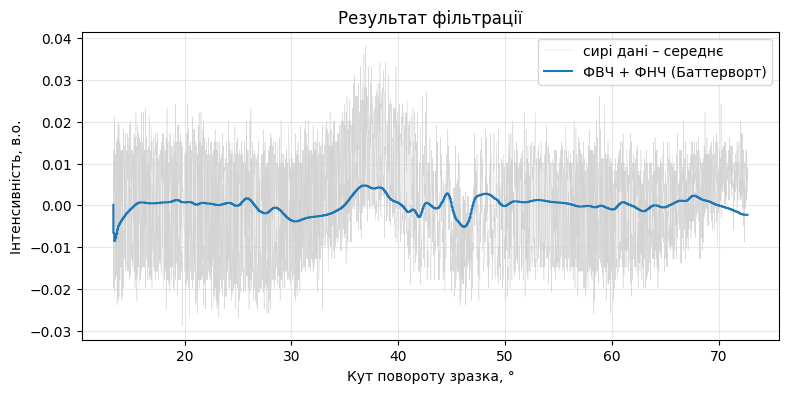

In [12]:
LP_WN = 0.004
y_f = lowpass(y_hp, LP_WN)               # основний відфільтрований сигнал
fig, ax = plt.subplots()
ax.plot(x, y - y.mean(), color="lightgray", lw=0.3, label="сирі дані – середнє")
ax.plot(x, y_f, "tab:blue", lw=1.5, label="ФВЧ + ФНЧ (Баттерворт)")
ax.set_xlabel("Кут повороту зразка, °"); ax.set_ylabel("Інтенсивність, в.о."); ax.set_title("Результат фільтрації"); ax.legend()
fig.savefig("figures/t2_2res.png", dpi=200, bbox_inches="tight"); plt.show()

### 2.3. Апроксимація
Поліном степеня 10 (x масштабуємо до середнього 0 і σ = 1, інакше задача погано обумовлена) і, для порівняння, синусоїда.
RMSE рахуємо відносно сирих даних; воно не може бути меншим за рівень шуму (σ ≈ 0,0096).

   степінь     RMSE
0        4  0.00929
1        6  0.00914
2        8  0.00894
3       10  0.00869
4       12  0.00857
Поліном 10: RMSE (до сирих) = 0.00869; RMSE (до відфільтрованого) = 0.00427
Синусоїда: RMSE = 0.00909, період ≈ 32.9°


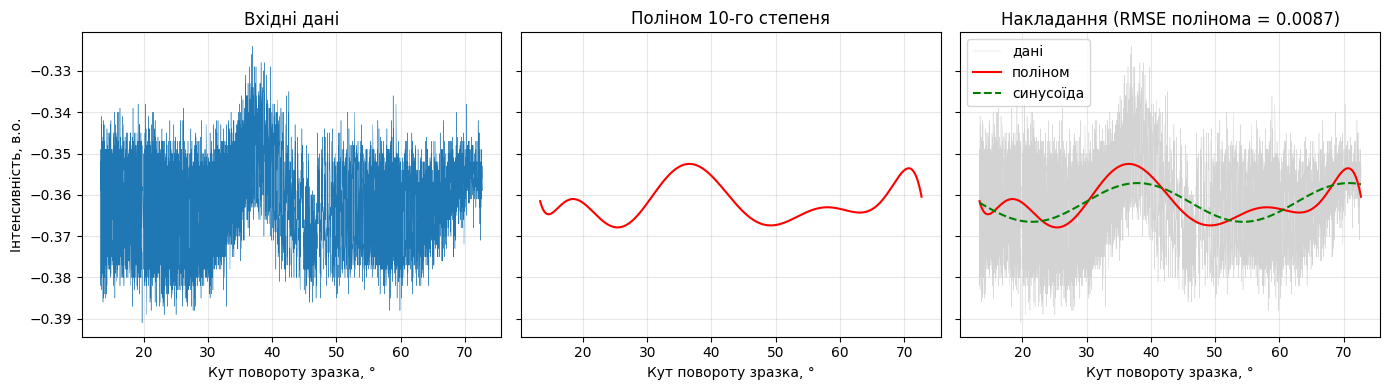

In [13]:
xs = (x - x.mean()) / x.std()
res = []
for deg in [4, 6, 8, 10, 12]:
    c = np.polyfit(xs, y, deg); res.append((deg, np.sqrt(np.mean((y - np.polyval(c, xs)) ** 2))))
print(pd.DataFrame(res, columns=["степінь", "RMSE"]).round(5))
DEG = 10
coef = np.polyfit(xs, y, DEG); y_poly = np.polyval(coef, xs)
rmse_poly = np.sqrt(np.mean((y - y_poly) ** 2))
rmse_poly_f = np.sqrt(np.mean((y_poly - (y_f + y.mean())) ** 2))
print(f"Поліном {DEG}: RMSE (до сирих) = {rmse_poly:.5f}; RMSE (до відфільтрованого) = {rmse_poly_f:.5f}")

def sine(x, A, w, ph, c): return A * np.sin(w * x + ph) + c
best = None
for period in [6, 9, 12, 18, 25, 40, 60]:
    try:
        po, _ = curve_fit(sine, x, y, p0=[y.std() * 1.4, 2 * np.pi / period, 0, y.mean()], maxfev=20000)
        r = np.sqrt(np.mean((y - sine(x, *po)) ** 2))
        if best is None or r < best[0]: best = (r, po)
    except RuntimeError:
        pass
rmse_sin, popt = best; y_sin = sine(x, *popt)
print(f"Синусоїда: RMSE = {rmse_sin:.5f}, період ≈ {2*np.pi/popt[1]:.1f}°")

fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
ax[0].plot(x, y, lw=0.3); ax[0].set_title("Вхідні дані")
ax[1].plot(x, y_poly, "r"); ax[1].set_title(f"Поліном {DEG}-го степеня")
ax[2].plot(x, y, color="lightgray", lw=0.3, label="дані"); ax[2].plot(x, y_poly, "r", label="поліном")
ax[2].plot(x, y_sin, "g--", label="синусоїда"); ax[2].set_title(f"Накладання (RMSE полінома = {rmse_poly:.4f})"); ax[2].legend()
for a in ax: a.set_xlabel("Кут повороту зразка, °")
ax[0].set_ylabel("Інтенсивність, в.о."); fig.tight_layout(); fig.savefig("figures/t2_3.png", dpi=200, bbox_inches="tight"); plt.show()

### 2.4. Нулі функції
Усі значення від'ємні (≈ –0,362), тому віднімаємо постійну складову. Нуль між двома відліками – лінійна інтерполяція.

Нулі сирого сигналу (I – середнє): 4220 (переважно шум)
Нулі відфільтрованого сигналу: 21 при куті, °: [13.32 15.35 24.71 25.06 26.56 34.94 40.32 42.44 43.06 43.94 45.   47.03
 49.76 50.21 56.49 60.62 61.85 63.97 64.15 65.38 69.97]


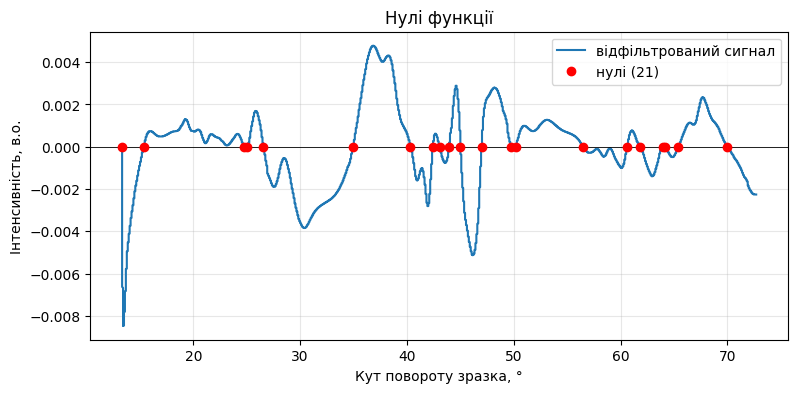

In [14]:
def zero_crossings(s):
    i = np.where(s[:-1] * s[1:] < 0)[0]
    return i - s[i] * 1.0 / (s[i + 1] - s[i])          # дробовий індекс (крок = 1 відлік)

z_raw = zero_crossings(y - y.mean())
z_f = zero_crossings(y_f)
z_ang = ang(z_f)
print(f"Нулі сирого сигналу (I – середнє): {len(z_raw)} (переважно шум)")
print(f"Нулі відфільтрованого сигналу: {len(z_f)} при куті, °:", np.round(z_ang, 2))

fig, ax = plt.subplots()
ax.plot(x, y_f, label="відфільтрований сигнал"); ax.axhline(0, color="black", lw=0.6)
ax.plot(z_ang, np.zeros_like(z_ang), "ro", label=f"нулі ({len(z_f)})")
ax.set_xlabel("Кут повороту зразка, °"); ax.set_ylabel("Інтенсивність, в.о."); ax.set_title("Нулі функції"); ax.legend()
fig.savefig("figures/t2_4.png", dpi=200, bbox_inches="tight"); plt.show()

### 2.5. Максимуми і мінімуми (`find_peaks`, prominence = 0,002)

     тип  кут, °  I, в.о.
 мінімум  13.412  -0.0085
максимум  25.853   0.0017
 мінімум  30.441  -0.0038
максимум  36.882   0.0048
 мінімум  42.000  -0.0028
максимум  44.647   0.0029
 мінімум  46.147  -0.0051
максимум  48.176   0.0028
 мінімум  63.000  -0.0014
максимум  67.676   0.0023
Максимумів: 5 Мінімумів: 5


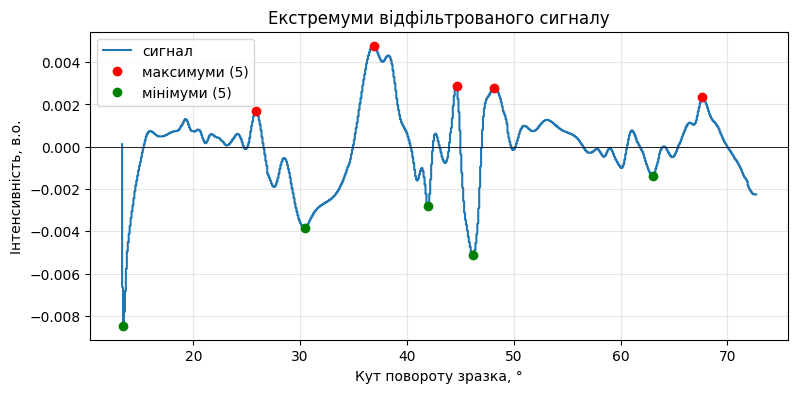

In [15]:
PROM = 0.002
pk, _ = find_peaks(y_f, prominence=PROM); tr, _ = find_peaks(-y_f, prominence=PROM)
ext = pd.concat([pd.DataFrame({"тип": "максимум", "кут, °": ang(pk), "I, в.о.": y_f[pk]}),
                 pd.DataFrame({"тип": "мінімум", "кут, °": ang(tr), "I, в.о.": y_f[tr]})]).sort_values("кут, °").round(4)
ext.to_csv("extrema.csv", index=False)
print(ext.to_string(index=False)); print("Максимумів:", len(pk), "Мінімумів:", len(tr))
fig, ax = plt.subplots()
ax.plot(x, y_f, label="сигнал"); ax.axhline(0, color="black", lw=0.6)
ax.plot(x[pk], y_f[pk], "ro", label=f"максимуми ({len(pk)})"); ax.plot(x[tr], y_f[tr], "go", label=f"мінімуми ({len(tr)})")
ax.set_xlabel("Кут повороту зразка, °"); ax.set_ylabel("Інтенсивність, в.о."); ax.set_title("Екстремуми відфільтрованого сигналу"); ax.legend()
fig.savefig("figures/t2_5.png", dpi=200, bbox_inches="tight"); plt.show()

### 2.6. Точки перегину (зміна знака другої похідної)
Похідні беремо по номеру виміру. Точку перегину з майже нульовим нахилом (|f′| < 5 % від максимального)
вважаємо «підозрілою»: на такій ділянці крива пологa, і її легко сплутати з екстремумом.

 кут, °  I, в.о.  нахил |f'|/max  підозріла (пологa)
 13.676  -0.0067          0.2150               False
 14.118  -0.0036          0.1027               False
 14.382  -0.0026          0.1146               False
 14.912  -0.0009          0.0912               False
 15.176  -0.0004          0.0928               False
 16.412   0.0006          0.0253                True
 17.647   0.0006          0.0213                True
 18.353   0.0007          0.0024                True
 18.971   0.0010          0.0454                True
 19.588   0.0010          0.0493                True
 20.294   0.0008          0.0138                True
 20.824   0.0004          0.0471                True
 21.353   0.0004          0.0400                True
 21.882   0.0005          0.0156                True
 22.235   0.0004          0.0048                True
 22.765   0.0002          0.0309                True
 23.559   0.0002          0.0259                True
 23.647   0.0003          0.0253              

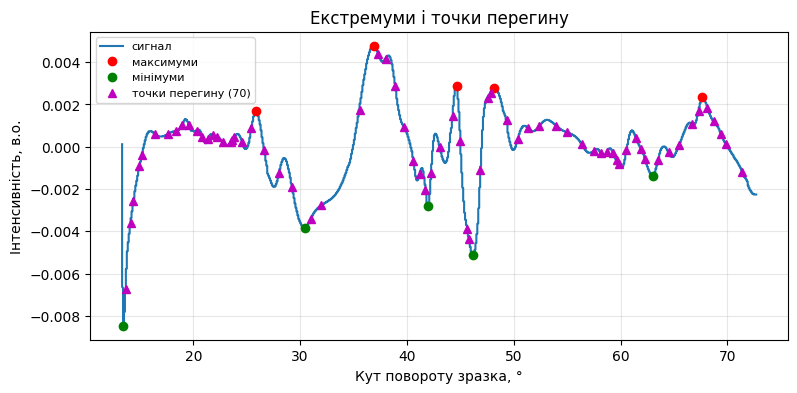

In [16]:
d1 = np.gradient(y_f); d2 = np.gradient(d1)
ii = np.where(np.sign(d2[:-1]) * np.sign(d2[1:]) < 0)[0]
infl = pd.DataFrame({"кут, °": ang(ii), "I, в.о.": y_f[ii], "нахил |f'|/max": np.abs(d1[ii]) / np.abs(d1).max()})
infl["підозріла (пологa)"] = infl["нахил |f'|/max"] < 0.05
infl = infl.round(4); infl.to_csv("inflection.csv", index=False); print(infl.to_string(index=False))
n_all_ext = int(np.sum(np.sign(d1[:-1]) * np.sign(d1[1:]) < 0))
print("Точок перегину:", len(ii), "| з них підозрілих:", int(infl["підозріла (пологa)"].sum()))
print("Усі зміни знаку f' (екстремуми без prominence):", n_all_ext, "| у п.5 (з prominence):", len(pk) + len(tr))

fig, ax = plt.subplots()
ax.plot(x, y_f, label="сигнал")
ax.plot(x[pk], y_f[pk], "ro", label="максимуми"); ax.plot(x[tr], y_f[tr], "go", label="мінімуми")
ax.plot(x[ii], y_f[ii], "m^", label=f"точки перегину ({len(ii)})")
ax.set_xlabel("Кут повороту зразка, °"); ax.set_ylabel("Інтенсивність, в.о."); ax.set_title("Екстремуми і точки перегину"); ax.legend(fontsize=8)
fig.savefig("figures/t2_6.png", dpi=200, bbox_inches="tight"); plt.show()

### 2.7. Інші фільтри (ковзне середнє, Савіцького–Голея, медіанний) поряд з Баттервортом
Вікна підібрано так, щоб вони були порівнянні з ФНЧ Баттерворта (період зрізу ≈ 500 відліків).

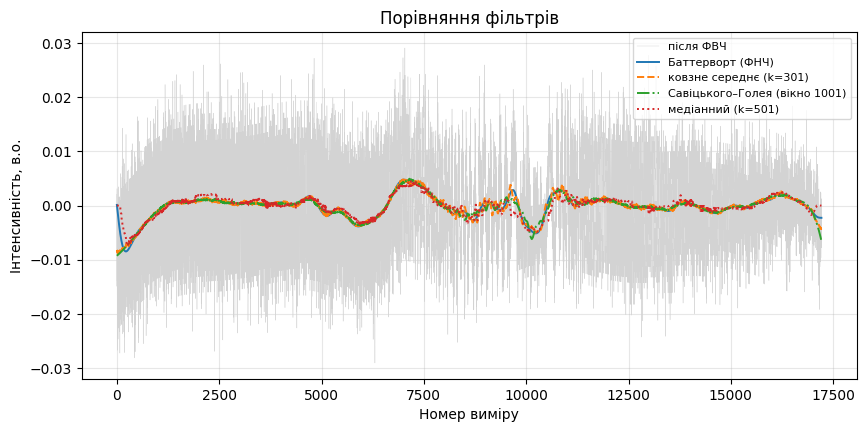

In [17]:
K_MA, K_SG, K_MED = 301, 1001, 501
y_ma  = pd.Series(y_hp).rolling(K_MA, center=True, min_periods=1).mean().values
y_sg  = savgol_filter(y_hp, K_SG, 3)
y_med = medfilt(y_hp, K_MED)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(n, y_hp, color="lightgray", lw=0.3, label="після ФВЧ")
for s, l, st in [(y_f, "Баттерворт (ФНЧ)", "-"), (y_ma, f"ковзне середнє (k={K_MA})", "--"),
                 (y_sg, f"Савіцького–Голея (вікно {K_SG})", "-."), (y_med, f"медіанний (k={K_MED})", ":")]:
    ax.plot(n, s, st, lw=1.4, label=l)
ax.set_xlabel("Номер виміру"); ax.set_ylabel("Інтенсивність, в.о."); ax.set_title("Порівняння фільтрів"); ax.legend(fontsize=8)
fig.savefig("figures/t2_7.png", dpi=200, bbox_inches="tight"); plt.show()

### 2.8. Кількість максимумів без фільтрації та з фільтруванням

In [18]:
def count_max(s, prom=None):
    return len(find_peaks(s, prominence=prom)[0]) if prom else len(find_peaks(s)[0])
tab = [("без фільтра, без prominence", count_max(y)),
       ("без фільтра, prominence = 0,002", count_max(y_hp, PROM))]
for w in [0.001, 0.004, 0.01, 0.05]:
    tab.append((f"Баттерворт ФНЧ Wn = {w}", count_max(lowpass(y_hp, w), PROM)))
tab += [(f"ковзне середнє k = {k}", count_max(pd.Series(y_hp).rolling(k, center=True, min_periods=1).mean().values, PROM)) for k in (51, 301, 901)]
tab += [(f"Савіцького–Голея вікно {k}", count_max(savgol_filter(y_hp, k, 3), PROM)) for k in (101, 1001, 3001)]
tab += [(f"медіанний k = {k}", count_max(medfilt(y_hp, k), PROM)) for k in (101, 501, 1501)]
cmp = pd.DataFrame(tab, columns=["варіант", "кількість максимумів"]); cmp.to_csv("maxima_comparison.csv", index=False)
print(cmp.to_string(index=False))

                        варіант  кількість максимумів
    без фільтра, без prominence                  5738
без фільтра, prominence = 0,002                  4966
      Баттерворт ФНЧ Wn = 0.001                     3
      Баттерворт ФНЧ Wn = 0.004                     5
       Баттерворт ФНЧ Wn = 0.01                    18
       Баттерворт ФНЧ Wn = 0.05                   162
          ковзне середнє k = 51                   183
         ковзне середнє k = 301                    11
         ковзне середнє k = 901                     5
     Савіцького–Голея вікно 101                   133
    Савіцького–Голея вікно 1001                     5
    Савіцького–Голея вікно 3001                     4
              медіанний k = 101                   177
              медіанний k = 501                    11
             медіанний k = 1501                     3


## Завдання №3. Фрагмент наукового звіту
Рисунки 2–3, таблиця характерних точок (`extrema.csv`) і висновки зібрані у файлі `Lab2_Variant1_report.pdf`.